In [1]:
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.gridspec import GridSpec
plt.style.use('style.mplstyle')

In [2]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [11]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
features_cols = ['burst',
                 'delayed:age',
                 'delayed:massformed',
                 'delayed:metallicity',
                 'delayed:tau',
                 'dust:Av',
                 'nebular:logU',
                 'stellar_mass',
                 'formed_mass',
                 'sfr',
                 'ssfr',
                 'mass_weighted_age',
                 'mass_weighted_zmet', 
                'redshift']



features = pd.read_csv('Features_with_Continuum.txt', sep = ' ', index_col = 0)

yval = pd.read_csv('Predictions_with_Continuum.txt', sep = ' ', index_col = 0)


good_chi2_mask = (features.chisq_phot.values < 100) & (features.chisq_phot.values > 0)
good_sn_mask = yval.sn.values > 5.3


mask = good_chi2_mask & good_sn_mask

good_data = features[mask]
good_yvals = yval[mask]


remove_bad_EW = good_yvals.EW_r < 500

good_data = good_data[remove_bad_EW]
good_yvals = good_yvals[remove_bad_EW]

merge_df = good_data.join(good_yvals)


def remove_outliers_IQR(data):

    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    data_no_outliers = data[~outliers]
    
    return data_no_outliers, outliers

In [5]:
class NN_Model_4_Layers(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3):
        
        super(NN_Model_4_Layers, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.fc4 = nn.Linear(hidden_size3, 1)
        #self.soft = nn.Softplus()

    def forward(self, x):
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc4(x)
        
        #
        #x = F.softmax(x, dim=1)
        #x = self.relu(x)
        #x = self.dropout(x)
        return x

In [6]:
feature_df = good_data[features_cols]
y_val_df = good_yvals[['EW_r']]

feature_df = good_data[features_cols]

feature_df['sfr'] = np.log10(feature_df['sfr'].values)
y_val_df = good_yvals[['EW_r']]



/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_39351/833903360.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_df['sfr'] = np.log10(feature_df['sfr'].values)


In [7]:
plot_labels = {'burst': 'Burstiness',
                'delayed:age': "Age [Gyr]",
                'delayed:massformed': r'Mass Formed [M$_\odot$]',
                'delayed:metallicity': 'Metallicity',
                'delayed:tau': r'$\tau$ [Gyr]',
                'dust:Av': 'Av',
                'nebular:logU': 'logU',
                'stellar_mass': r'Stellar Mass [M$_\odot$]',
                'formed_mass': r'Formed Mass [M$_\odot$]',
                'sfr': 'SFR [M$_\odot$ yr$^{-1}$]',
                'ssfr': 'sSFR [yr$^{-1}$]',
                'mass_weighted_age': 'Mass Weighted Age [Gyr]',
                'mass_weighted_zmet': 'Mass Weighted Metallicity',
                'redshift': 'Redshift'}

<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\o'
/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_39351/3584760394.py:10: SyntaxWarning: invalid escape sequence '\o'
  'sfr': 'SFR [M$_\odot$ yr$^{-1}$]',


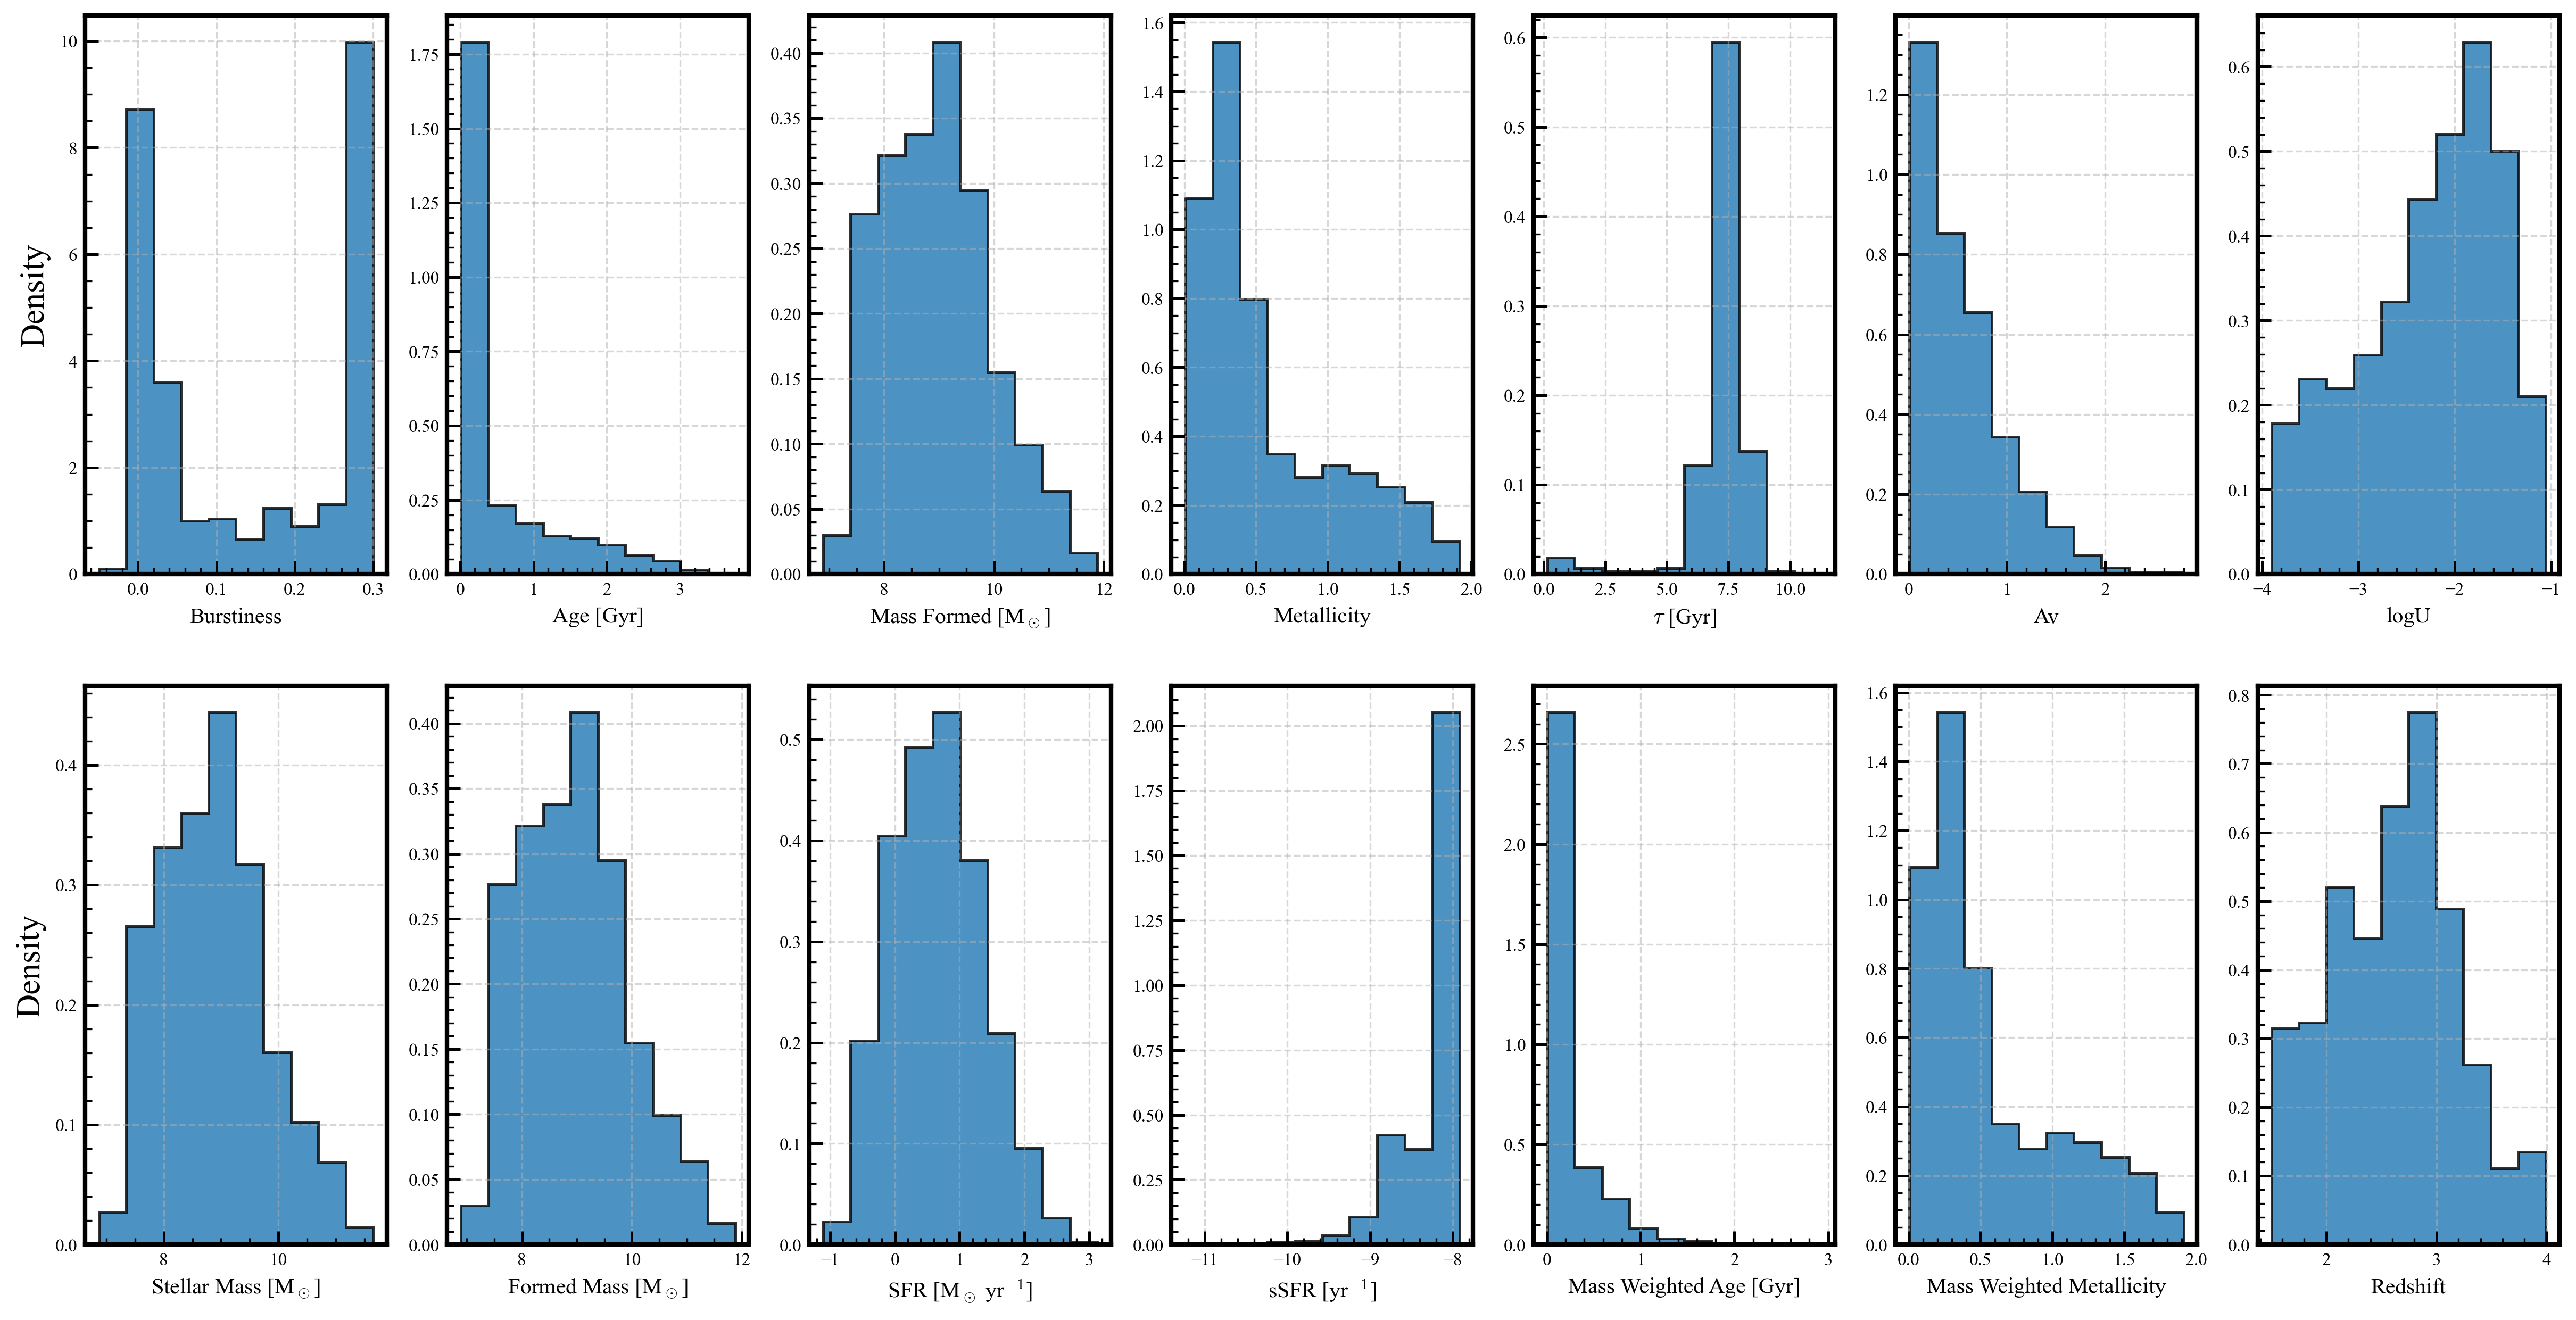

In [ ]:
gs = GridSpec(2, 7)
fig = plt.figure(figsize=(20, 10))
axes = []
for i in range(14):
    row = i // 7
    col = i % 7
    ax = fig.add_subplot(gs[row, col])
    #ax.set_title(features_cols[i])
    #ax.set_ylabel('EW_r')
    ax.set_xlabel(plot_labels[features_cols[i]])
    ax.hist(feature_df[features_cols[i]],
            edgecolor='black',      # Border color
            linewidth=1.2,          # Border thickness
            alpha=0.8,              # Transparency
            density=True,           # Normalize to 1 if needed
            histtype='stepfilled')
    ax.grid(True, linestyle='--', alpha=0.5)
    axes.append(ax)

axes[0].set_ylabel('Density', fontsize = 15)
axes[7].set_ylabel('Density', fontsize = 15)
plt.show()

In [1]:
# gs = GridSpec(2, 7)
# fig = plt.figure(figsize=(20, 10))
# axes = []

# for i, cols in enumerate(features_cols):
    
#     row = i // 7
#     col = i % 7

#     ax = fig.add_subplot(gs[row, col])
#     sb.boxplot(data=feature_df[cols], color='blue')

# Using K-Fold Validation on NN

In [8]:
from sklearn.model_selection import KFold

In [64]:
X_train, X_test, y_train, y_test = train_test_split(feature_df, 
                                                    np.log10(y_val_df), 
                                                    test_size=0.2, 
                                                    random_state=423423)



In [23]:
# gs = GridSpec(2, 7)
# fig = plt.figure(figsize=(20, 10))
# axes = []
# for i in range(14):
#     row = i // 7
#     col = i % 7
#     ax = fig.add_subplot(gs[row, col])
#     #ax.set_title(features_cols[i])
#     #ax.set_ylabel('EW_r')
#     ax.set_xlabel(features_cols[i])
#     ax.scatter(X_train[features_cols[i]], 
#                y_train['EW_r'], 
#                alpha=0.5, 
#                label = 'Train', 
#                color = 'blue', s=10)
#     ax.scatter(X_test[features_cols[i]], 
#                y_test['EW_r'], 
#                alpha=0.5, label = 'Test', 
#                color = 'red', s = 10)
#     ax.legend()
#     axes.append(ax)

# axes[0].set_ylabel('EW_r')
# axes[7].set_ylabel('EW_r')
# plt.show()

In [60]:
log10_y_val_df = np.log10(y_val_df)

In [ ]:
epochs = 1000
batch_size = 32
learning_rate = 0.01

criterion = nn.MSELoss()

val_losses = []

kf = KFold(n_splits=5, shuffle=True, random_state=4232)
plt.figure(figsize = (10, 5), constrained_layout = True)

model = NN_Model_4_Layers(len(features_cols),
                            128, 64, 32)

losses_per_epoch = []

for train_idx, val_idx in kf.split(X_train):

    # Split data
    scale_x = StandardScaler()
    scale_y = StandardScaler()

    X_train_scaled = scale_x.fit_transform(feature_df.iloc[train_idx])
    X_test_scaled = scale_x.transform(feature_df.iloc[val_idx])


    Y_train = log10_y_val_df.iloc[train_idx]
    Y_test = log10_y_val_df.iloc[val_idx]

    X_train1, X_val = torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(X_test_scaled, dtype=torch.float32)
    y_train1, y_val = torch.tensor(Y_train.values, dtype=torch.float32).view(-1, 1), torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)


    
    losses = []
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(X_train1)

        
        loss = criterion(y_train1, outputs)
        losses.append(loss.detach().numpy())
        # Backward pass
        loss.backward()
        optimizer.step()
    
    losses_per_epoch.append(losses)

    model.eval()

    with torch.no_grad():
        val_outputs = model(X_val)

        val_loss = criterion(y_val, val_outputs)

    
    # Store validation loss for this fold
    val_losses.append(val_loss.item())

<Figure size 3000x1500 with 0 Axes>

In [65]:
X_test_scaled = scale_x.transform(X_test)
X_test_torch, y_test = torch.tensor(X_test_scaled, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    
    test_outputs = model(X_test_torch)
    test_loss = criterion(test_outputs, y_test)

print(f'Test Loss: {test_loss.item()}')

Test Loss: 0.0195710901170969


In [30]:
coeffs = np.polyfit(y_test.numpy().flatten(), test_outputs.numpy().flatten(), 1)
poly_eqn = np.poly1d(coeffs)

In [66]:
print('Model with the K-Fold Cross-Validation')
print('MAE:', mean_absolute_error(test_outputs, y_test))
print('MSE:', mean_squared_error(test_outputs, y_test))
print('R2 Score:', r2_score(test_outputs, y_test))

Model with the K-Fold Cross-Validation
MAE: 0.10411439043783825
MSE: 0.019571089975701974
R2 Score: 0.6859316144565064


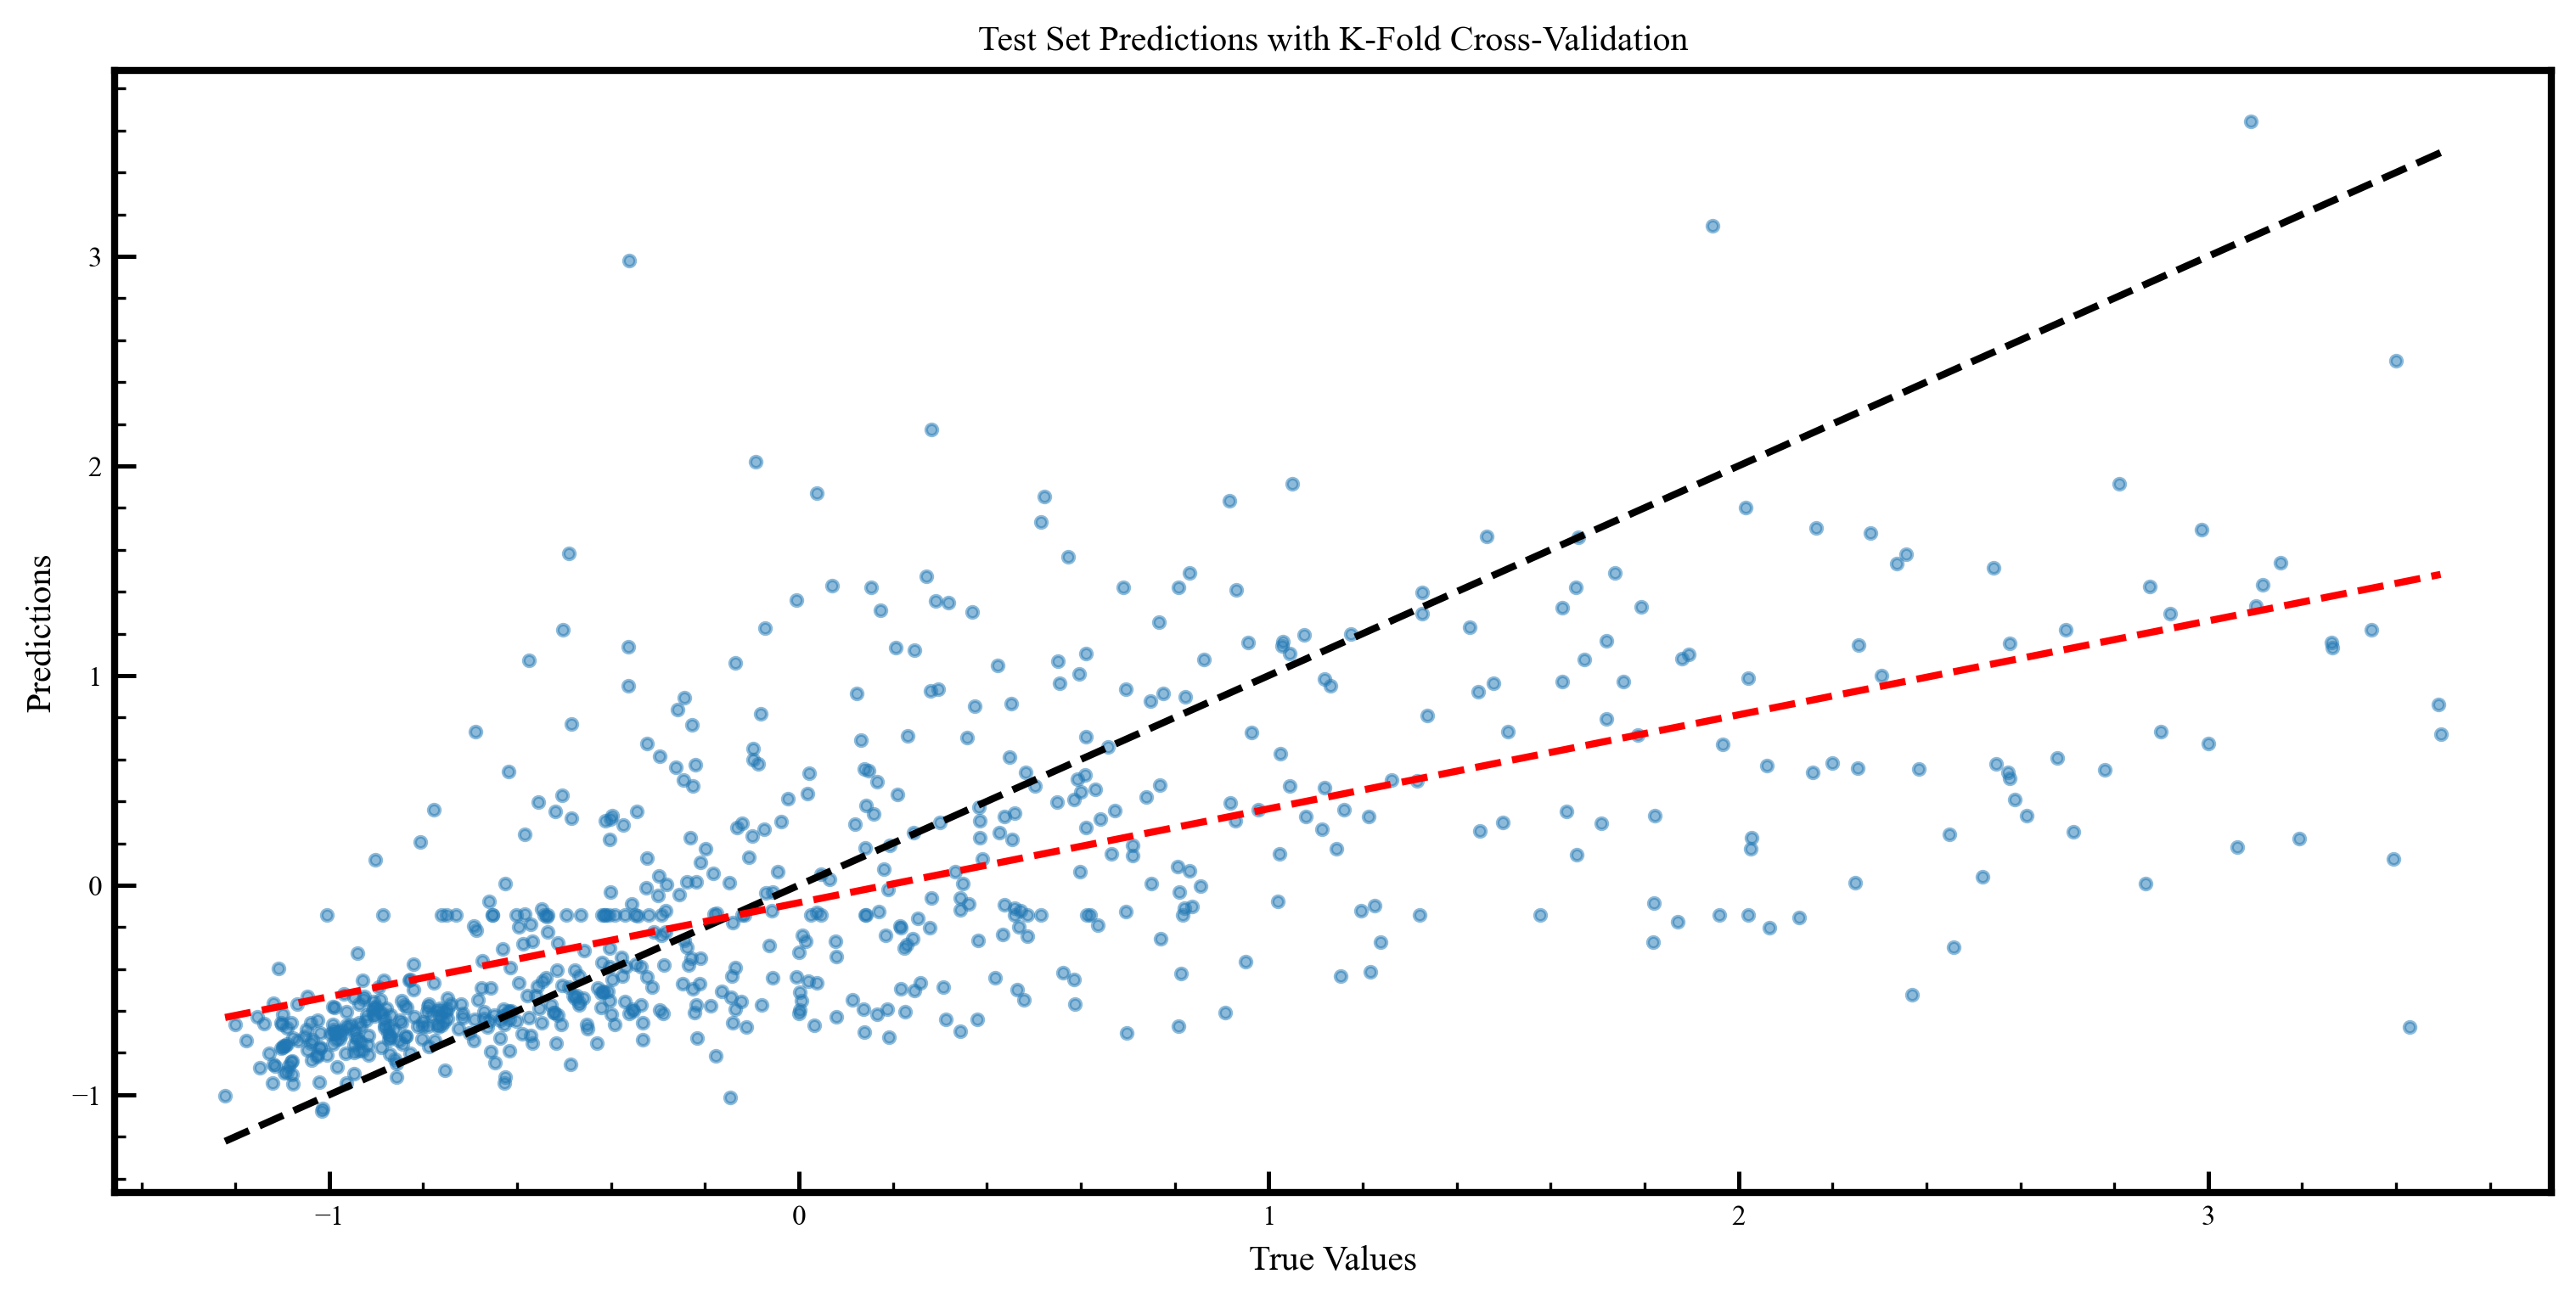

In [31]:
plt.figure(figsize=(10, 5), constrained_layout=True)
plt.scatter(y_test, test_outputs, alpha=0.5, s=10)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Test Set Predictions with K-Fold Cross-Validation')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
xarr = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(xarr, poly_eqn(xarr), 'r--', lw=2)

In [76]:
mean_squared_error(y_test, test_outputs), r2_score(y_test, test_outputs), mean_absolute_error(y_test, test_outputs)

(0.5813940373420944, 0.4517476875107981, 0.48176996375327613)

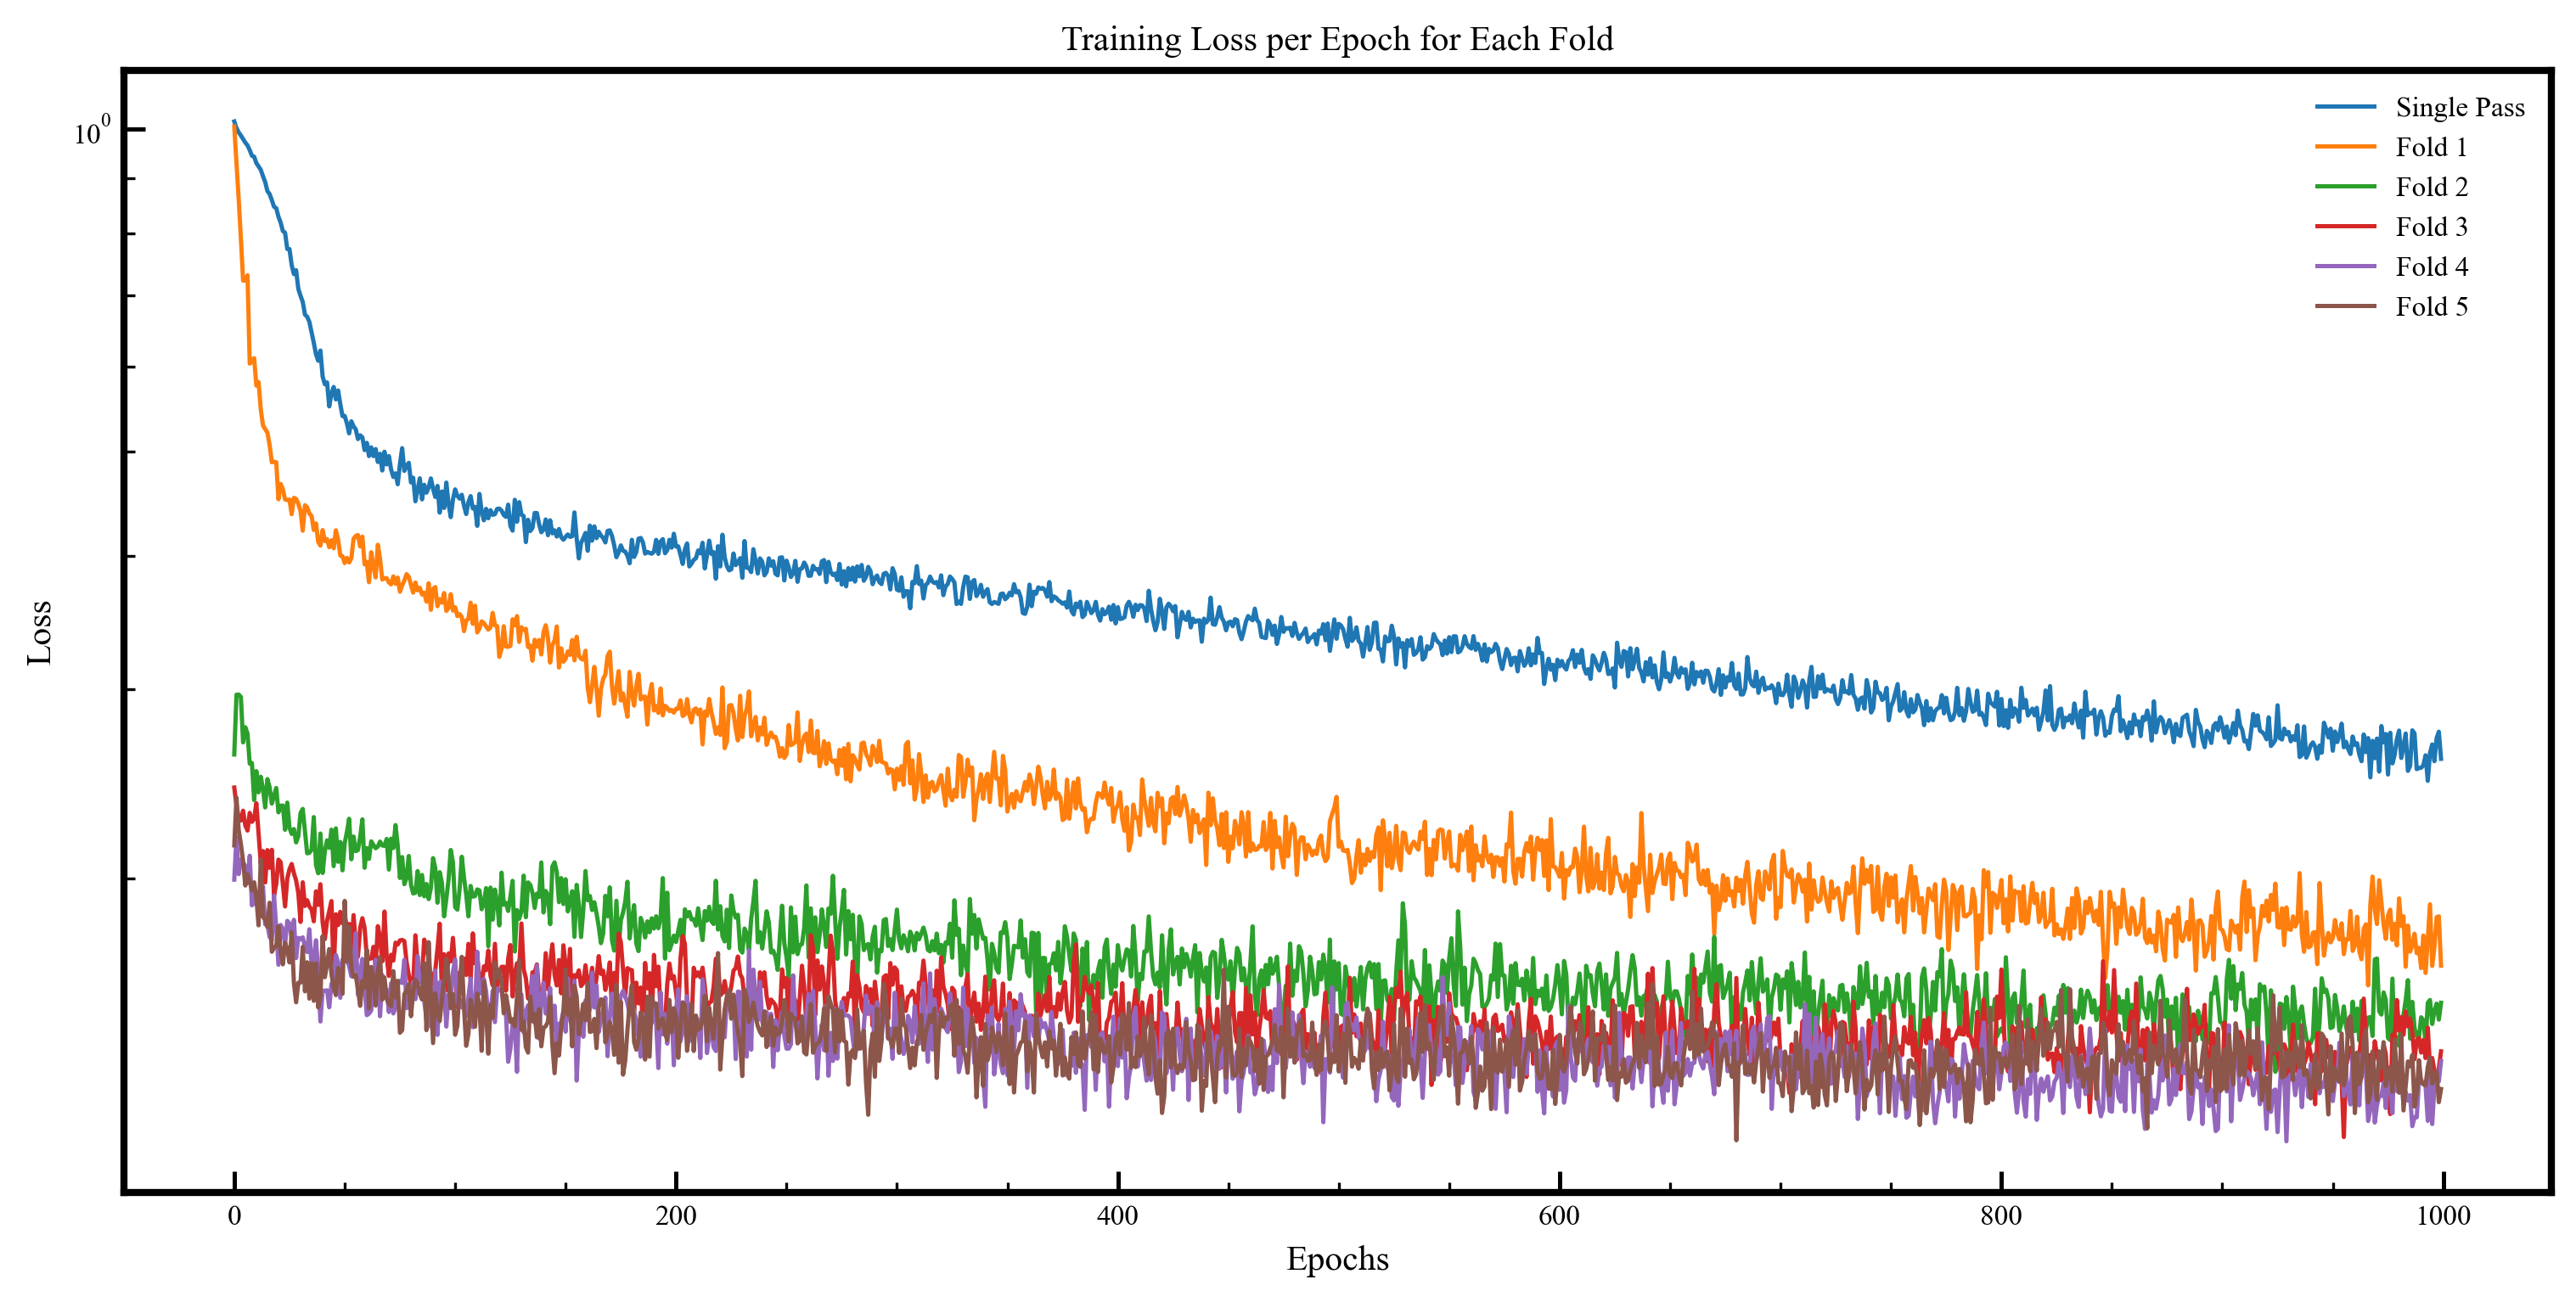

Average Validation Loss: 0.37700019478797914


In [57]:
plt.figure(figsize = (10, 5), constrained_layout = True)
plt.plot(losses_single_pass, label = 'Single Pass')
for i, fold_losses in enumerate(losses_per_epoch):
    plt.plot(fold_losses, label = f'Fold {i + 1}')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.yscale('log')
plt.title('Training Loss per Epoch for Each Fold')
plt.show()
# Print average validation loss across all folds
print(f"Average Validation Loss: {np.mean(val_losses)}")

In [22]:
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    val_outputs = model(X_test)
    val_loss = criterion(val_outputs, y_test)
    print(f"Test Loss: {val_loss.item()}")

Test Loss: 0.2905156910419464


In [33]:
coeffs = np.polyfit(y_test.numpy().flatten(), val_outputs.numpy().flatten(), 1)
poly_eqn = np.poly1d(coeffs)

/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_7673/1128311409.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x_arr, poly_eqn(x_arr), 'r-', lw=2, label='Line of Bias', color = 'purple')


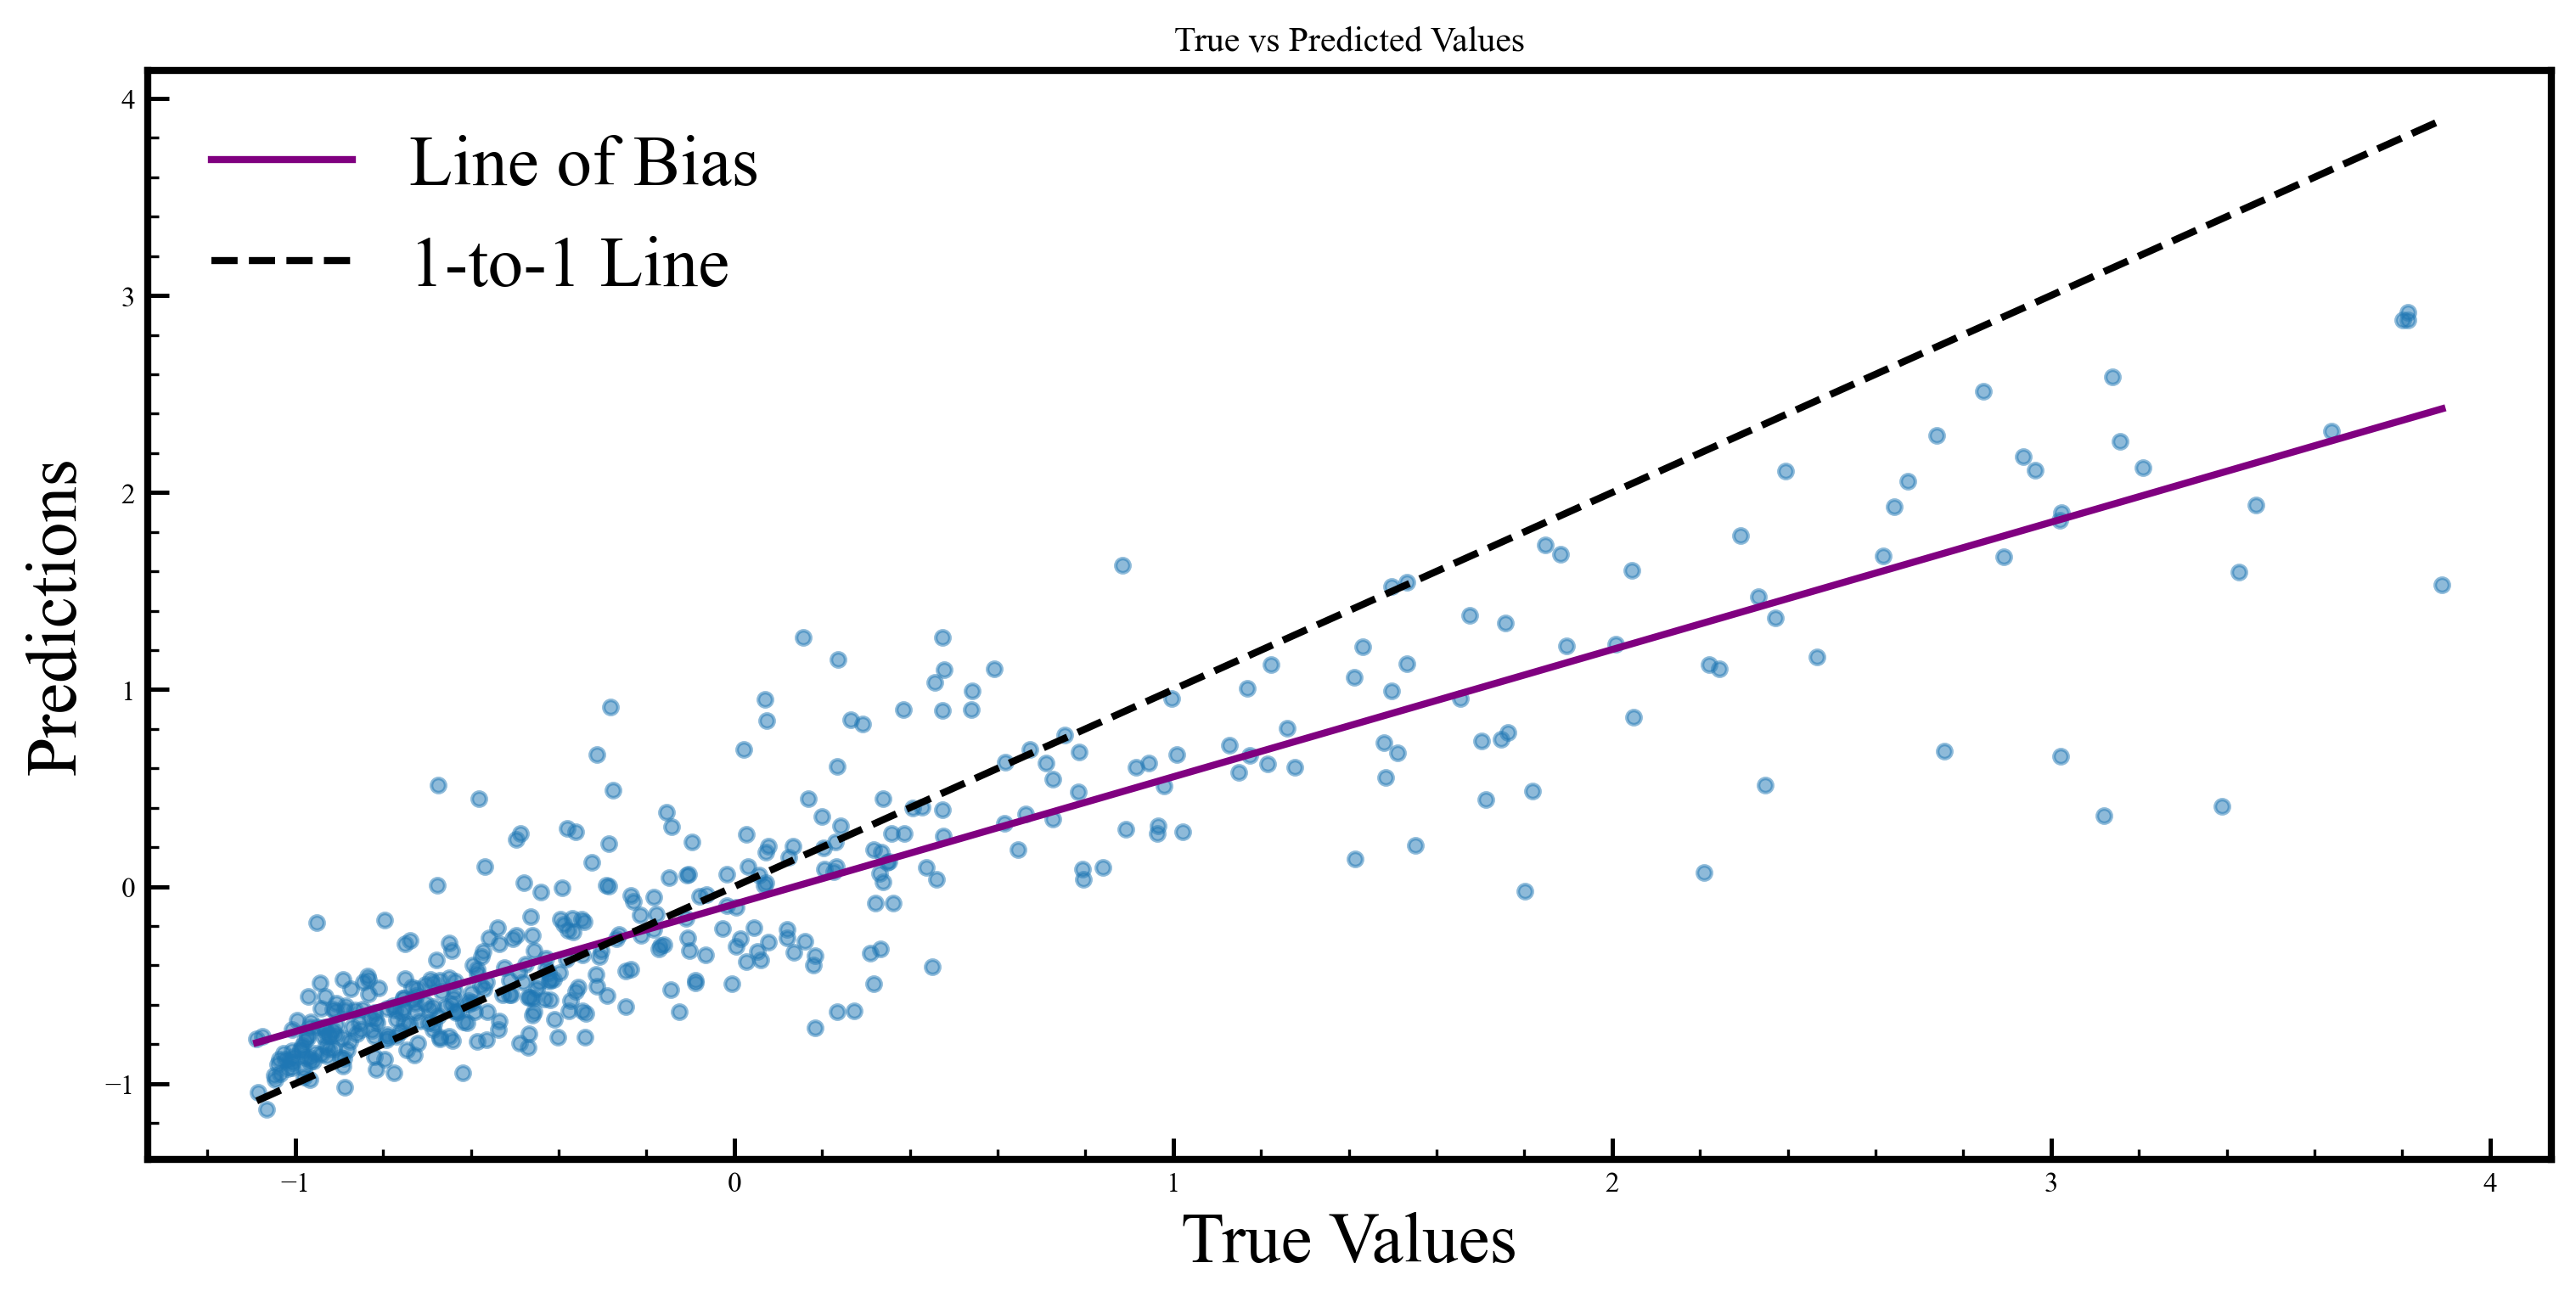

In [42]:
plt.figure(figsize = (10, 5), constrained_layout = True)
plt.scatter(y_test, val_outputs, alpha=0.5)
plt.xlabel('True Values', fontsize = 20)
plt.ylabel('Predictions', fontsize = 20)
plt.title('True vs Predicted Values')

x_arr = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_arr, poly_eqn(x_arr), 'r-', lw=2, label='Line of Bias', color = 'purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label = '1-to-1 Line')
plt.legend(fontsize = 20)


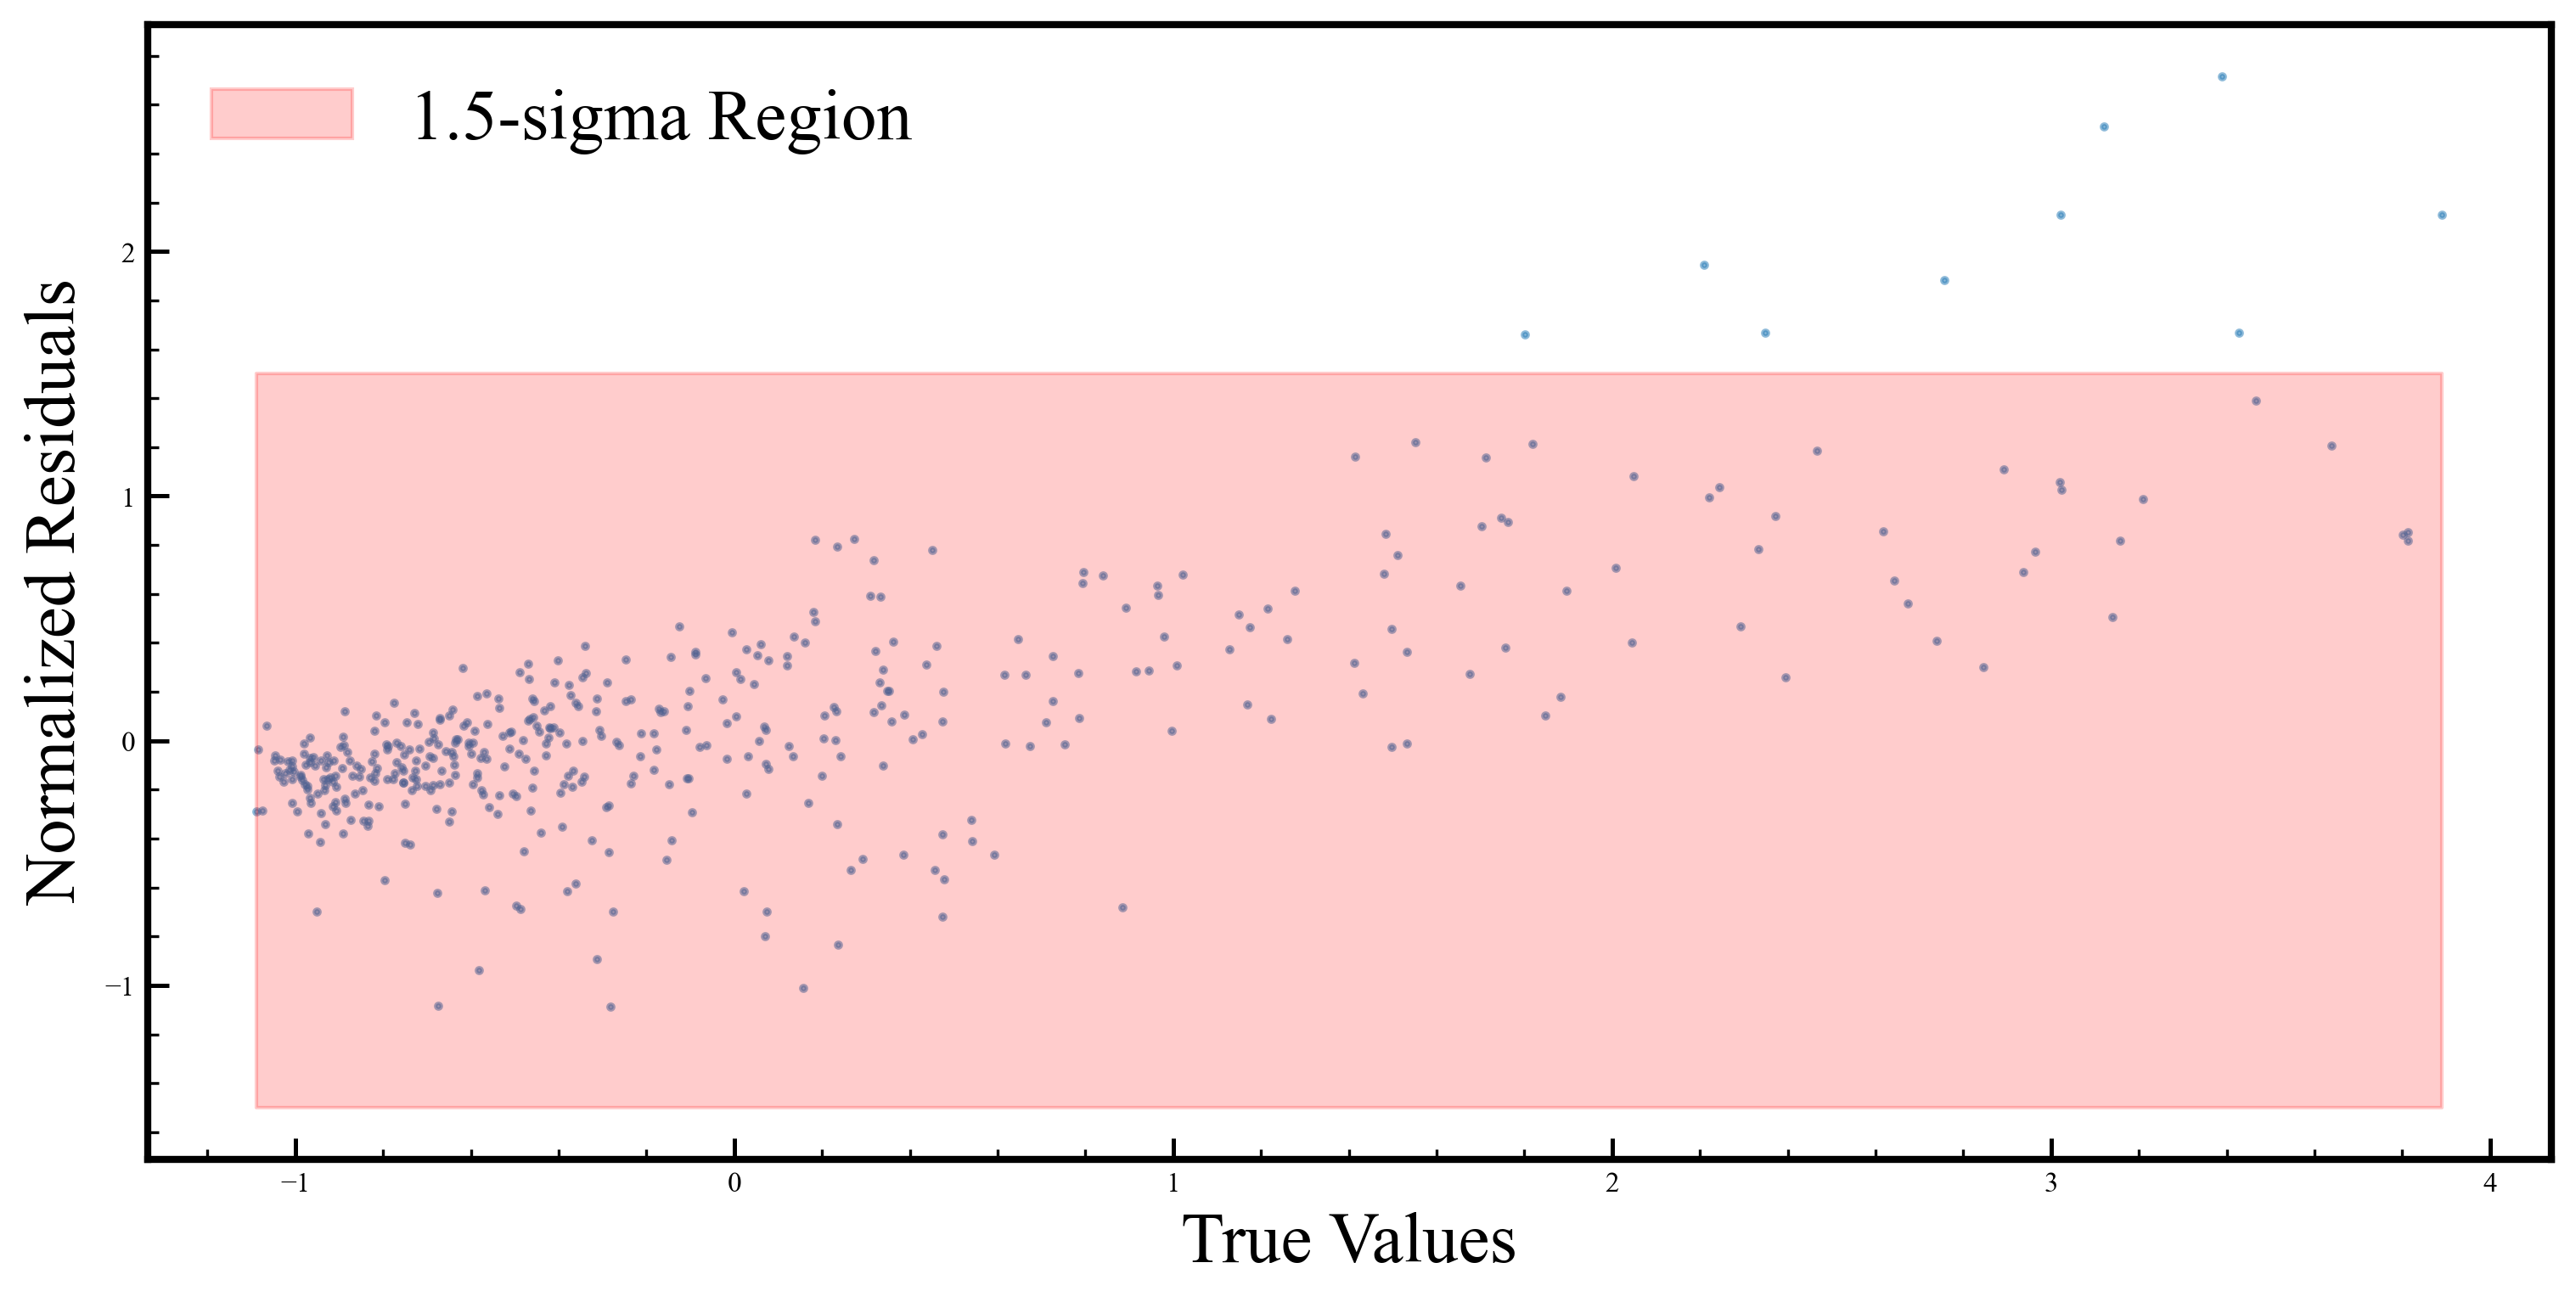

In [56]:
plt.figure(figsize = (10, 5), constrained_layout = True)
plt.scatter(y_test, ((y_test - val_outputs)/y_test.std()).numpy().flatten(), 
            s = 10, marker = '.', alpha = 0.5)
plt.xlabel('True Values', fontsize = 20)
plt.ylabel('Normalized Residuals', fontsize = 20)

sigma = 1.5

x_arr = np.linspace(y_test.min(), y_test.max(), 100)
plt.fill_between(x_arr, sigma*np.ones(100), -sigma*np.ones(100),
                 color = 'red', alpha = 0.2, label = f'{sigma}-sigma Region')
plt.legend(fontsize = 20)

In [34]:
error = val_loss.item()/y_test.std()

# Using Single NN Training Set

In [79]:
torch.manual_seed(4234623)

In [80]:
X_train, X_test, y_train, y_test = train_test_split(feature_df, 
                                                    y_val_df, 
                                                    test_size=0.2, 
                                                    random_state=423423)

In [81]:
scale = StandardScaler()

X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)


y_train_scaled = scale.fit_transform(y_train)
y_test_scaled = scale.transform(y_test)
X_train, y_train = torch.FloatTensor(X_train_scaled), torch.FloatTensor(y_train_scaled)
X_test, y_test = torch.FloatTensor(X_test_scaled), torch.FloatTensor(y_test_scaled)

In [82]:
epochs = 1000
losses_single_pass = []

model = NN_Model(len(features_cols), 
                 128, 64, 32)

#set criterion and optimizer
#Using the mse loss function
criterion = nn.MSELoss() #mean squared error
#criterion = nn.L1Loss() #mean absolute error
#criterion = nn.SmoothL1Loss() #combines MSE and MAE into one loss function

optimizer = optim.Adam(model.parameters(), lr=0.001)

#training loop

for epoch in range(epochs):
    #zero the parameter gradients
    #optimizer.zero_grad()
    
    #forward pass
    y_pred = model.forward(X_train)
    
    
    #calculate loss
    loss = criterion(y_pred, y_train)
    
    losses_single_pass.append(loss.detach().numpy())
    
    #update weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    

    if epoch % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 1/1000, Loss: 1.0168
Epoch 11/1000, Loss: 0.9298
Epoch 21/1000, Loss: 0.8287
Epoch 31/1000, Loss: 0.6991
Epoch 41/1000, Loss: 0.5877
Epoch 51/1000, Loss: 0.5399
Epoch 61/1000, Loss: 0.5096
Epoch 71/1000, Loss: 0.4953
Epoch 81/1000, Loss: 0.4681
Epoch 91/1000, Loss: 0.4618
Epoch 101/1000, Loss: 0.4611
Epoch 111/1000, Loss: 0.4264
Epoch 121/1000, Loss: 0.4425
Epoch 131/1000, Loss: 0.4367
Epoch 141/1000, Loss: 0.4229
Epoch 151/1000, Loss: 0.4164
Epoch 161/1000, Loss: 0.4041
Epoch 171/1000, Loss: 0.4222
Epoch 181/1000, Loss: 0.4138
Epoch 191/1000, Loss: 0.4034
Epoch 201/1000, Loss: 0.4078
Epoch 211/1000, Loss: 0.4044
Epoch 221/1000, Loss: 0.3908
Epoch 231/1000, Loss: 0.3814
Epoch 241/1000, Loss: 0.3834
Epoch 251/1000, Loss: 0.3956
Epoch 261/1000, Loss: 0.3830
Epoch 271/1000, Loss: 0.3863
Epoch 281/1000, Loss: 0.3898
Epoch 291/1000, Loss: 0.3811
Epoch 301/1000, Loss: 0.3718
Epoch 311/1000, Loss: 0.3763
Epoch 321/1000, Loss: 0.3834
Epoch 331/1000, Loss: 0.3740
Epoch 341/1000, Loss: 0.3

In [83]:
#Testing on the testing set
with torch.no_grad():
    y_test_pred = model.forward(X_test)
    test_loss = criterion(y_test_pred, y_test)
    
    print(f'Test Loss: {test_loss.item():.4f}')

Test Loss: 0.5104


In [84]:
print('Model with the K-Fold Cross-Validation')
print('MAE:', mean_absolute_error(y_test_pred, y_test))
print('MSE:', mean_squared_error(y_test_pred, y_test))
print('R2 Score:', r2_score(y_test_pred, y_test))

Model with the K-Fold Cross-Validation
MAE: 0.4643707860226552
MSE: 0.510384730981333
R2 Score: 0.19754242540513434


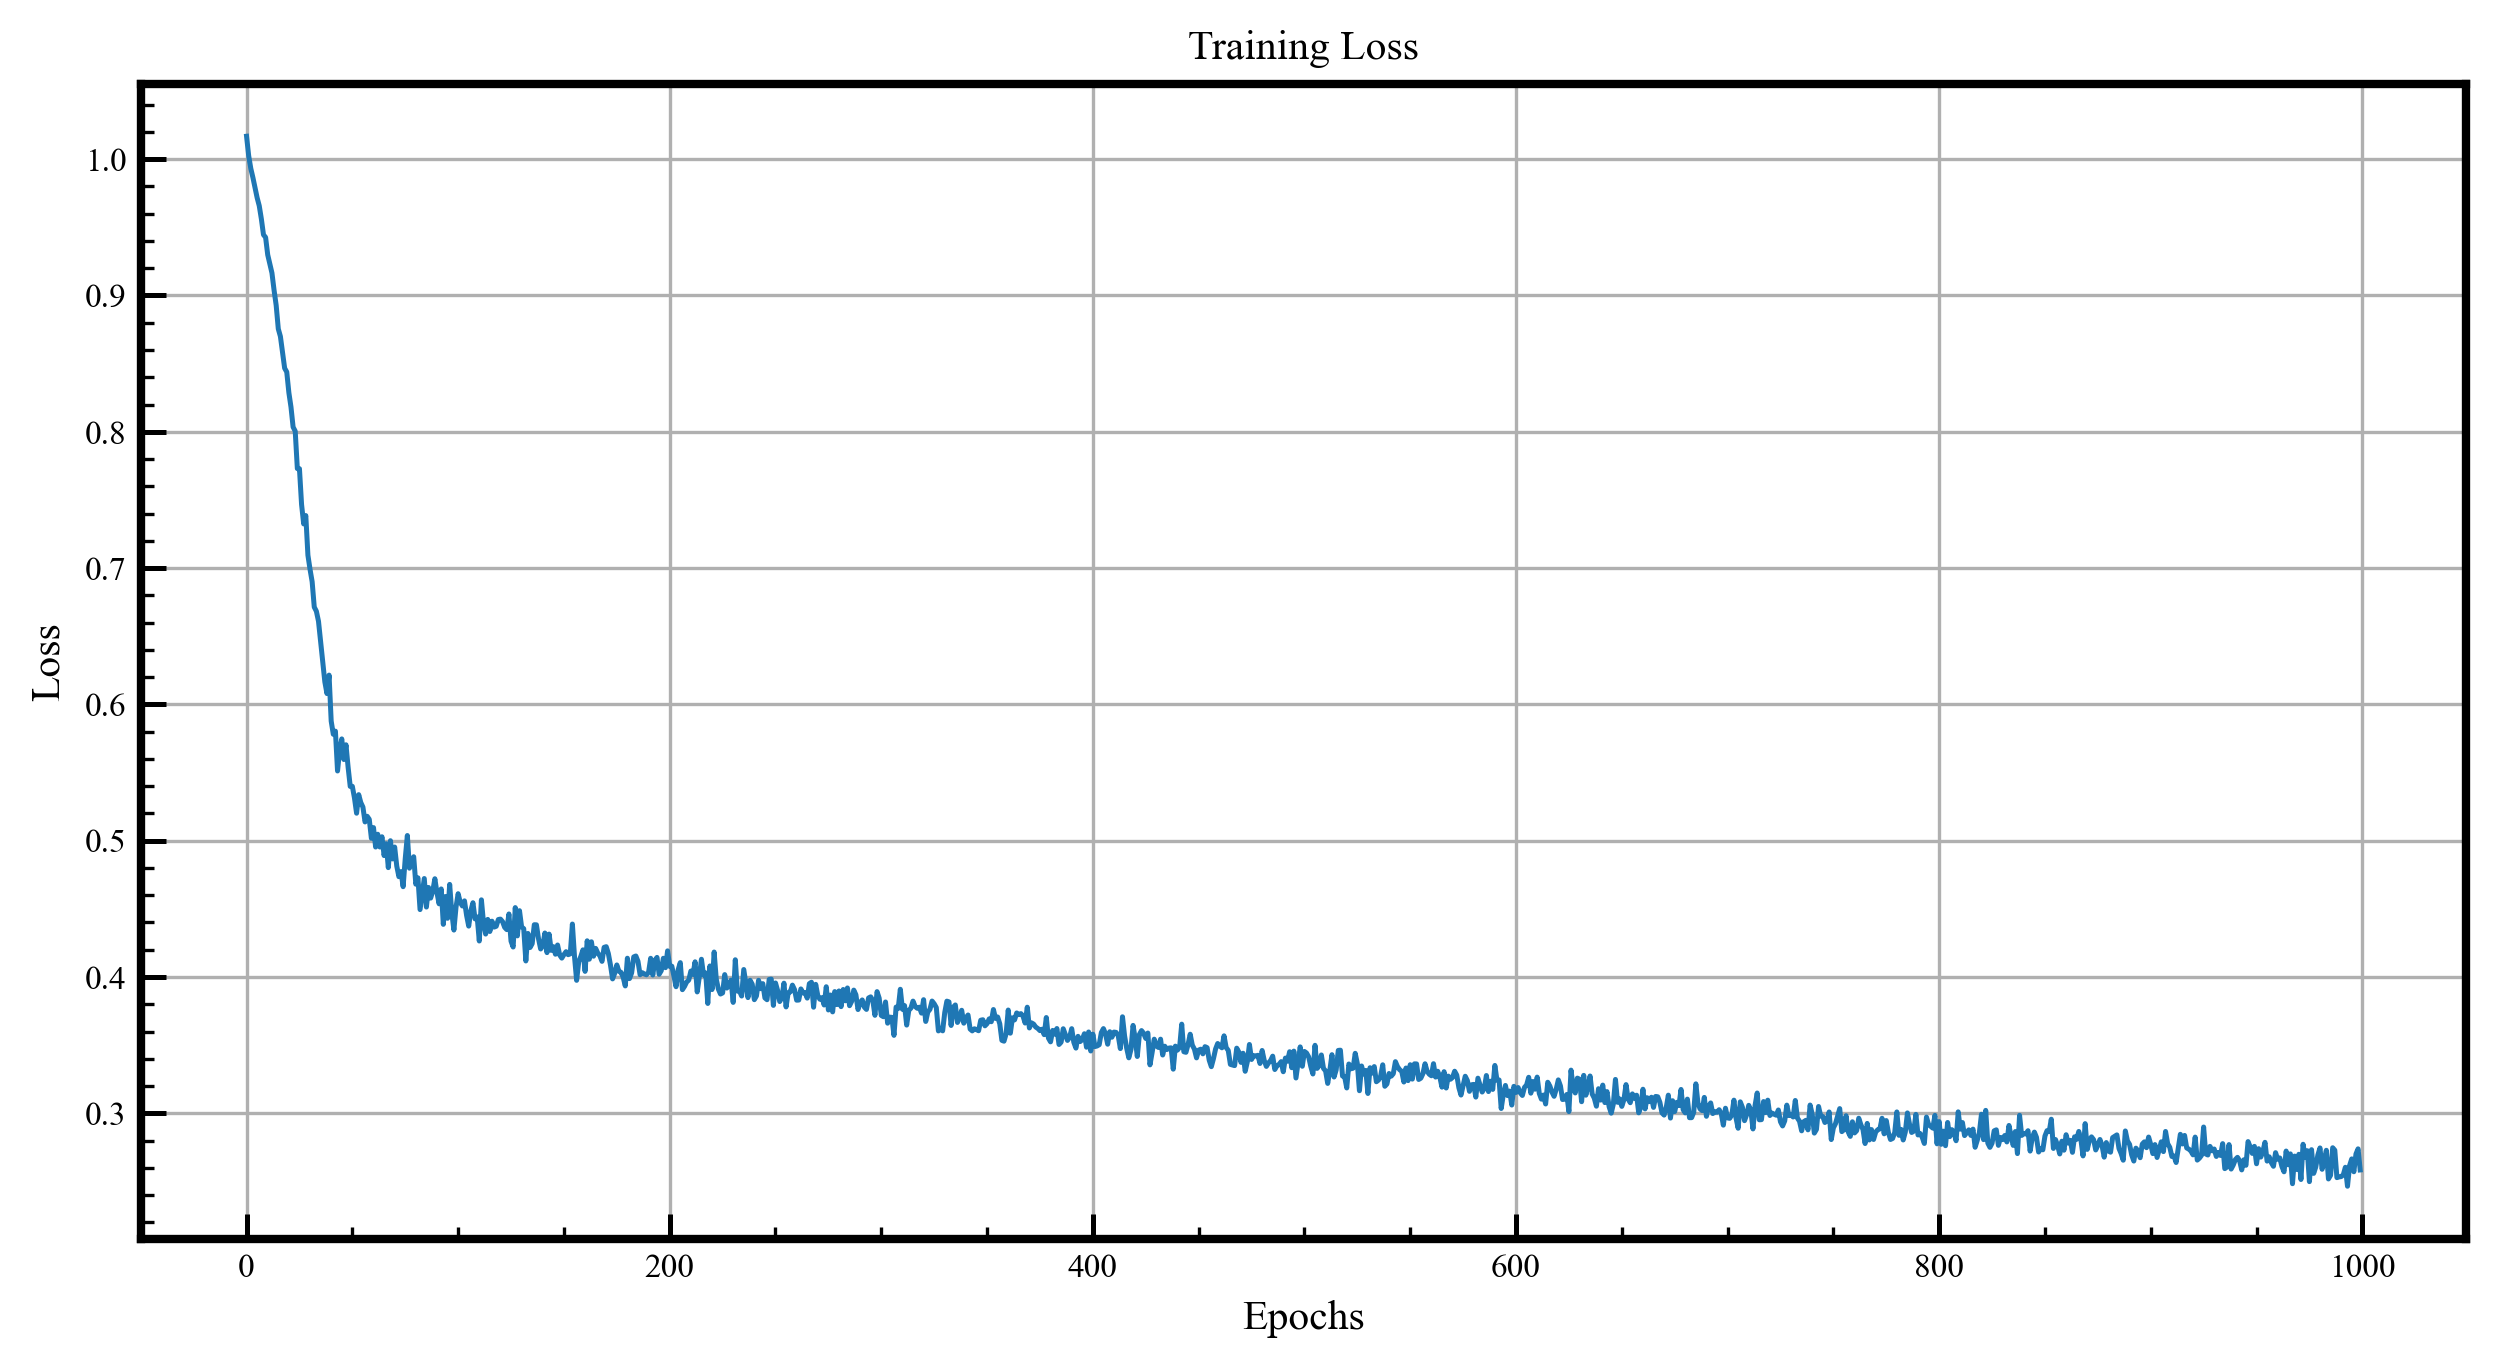

In [14]:
plt.figure(figsize = (10, 5))
plt.plot(losses_single_pass)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid()
plt.show()